# Step 5B: ETF Only Universe — Black-Litterman + 듀얼 모멘텀

## Step5A 대비 차이점

| 항목 | Step5A | Step5B (이 노트북) |
|------|--------|-----------------|
| **투자 유니버스** | S&P500 동적 주식(55종목) + 채권/대안 6개 | **ETF 22개 고정 유니버스** |
| **유니버스 구성** | 섹터별 시가총액 Top5 + 채권 ETF | 인덱스5 + 채권4 + 대안2 + 섹터11 |
| **동적 선정** | 1년마다 재선정 | 없음 — 고정 22개 |
| **모멘텀 필터** | 12-1 수익률 > T-bill | 동일 |

### 실험 목적
- 개별 종목 제거 시 횡단면 IC 개선 여부 확인
- ETF 유니버스에서 듀얼 모멘텀 BL 성능 검증

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
import warnings
import pickle
import yfinance as yf

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

BASE = Path('.')
DATA = BASE / 'data'
IMAGES = BASE / 'images'
CACHE = DATA / 'stock5b_cache'
DATA.mkdir(exist_ok=True)
IMAGES.mkdir(exist_ok=True)
CACHE.mkdir(exist_ok=True)

print('준비 완료')

준비 완료


## 셀 2: ETF 유니버스 정의 (22개)

In [2]:
# ── ETF 유니버스 (22개) ──────────────────────────────────────────────────
INDEX_ETF  = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']                          # 5개
BOND_ETF   = ['TLT', 'AGG', 'SHY', 'TIP']                                 # 4개
ALT_ETF    = ['GLD', 'DBC']                                                # 2개
SECTOR_ETF = ['XLK', 'XLF', 'XLE', 'XLV', 'VOX',
              'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']                 # 11개

# 투자 대상 전체 (Step5A의 BOND_TICKERS에 해당하는 '채권+대안' 분류 유지)
BOND_TICKERS  = BOND_ETF + ALT_ETF                                         # 6개 — 채권/대안
EQUITY_TICKERS = INDEX_ETF + SECTOR_ETF                                    # 16개 — 주식 ETF
ETF_UNIVERSE  = EQUITY_TICKERS + BOND_TICKERS                              # 22개 전체

# ── 섹터 분류 (IC 시각화용) ────────────────────────────────────────────────
ETF_TYPE = {}
for t in INDEX_ETF:  ETF_TYPE[t] = 'Index ETF'
for t in SECTOR_ETF: ETF_TYPE[t] = 'Sector ETF'
for t in BOND_ETF:   ETF_TYPE[t] = 'Bond ETF'
for t in ALT_ETF:    ETF_TYPE[t] = 'Alt ETF'

# ── 백테스트 파라미터 ─────────────────────────────────────────────────────
REBALANCE_FREQ = 21           # 21거래일마다 리밸런싱
ANALYSIS_START = '2016-01-01'
PRICE_START    = '2013-01-01'
PRICE_END      = '2025-12-31'
COV_WIN        = 252
TAU            = 1 / 252
LAM            = 2.5

print(f'ETF 유니버스: {len(ETF_UNIVERSE)}개')
print(f'  주식 ETF  (인덱스+섹터): {EQUITY_TICKERS}')
print(f'  채권/대안 ETF:           {BOND_TICKERS}')

ETF 유니버스: 22개
  주식 ETF  (인덱스+섹터): ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'XLK', 'XLF', 'XLE', 'XLV', 'VOX', 'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']
  채권/대안 ETF:           ['TLT', 'AGG', 'SHY', 'TIP', 'GLD', 'DBC']


## 셀 3: ETF 가격 데이터 수집

In [3]:
etf_cache = CACHE / 'etf_prices.pkl'

if etf_cache.exists():
    with open(etf_cache, 'rb') as f:
        etf_prices = pickle.load(f)
    print(f'캐시 로드: {etf_prices.shape}')
else:
    print(f'{len(ETF_UNIVERSE)}개 ETF 다운로드 중...')
    raw = yf.download(ETF_UNIVERSE, start=PRICE_START, end=PRICE_END,
                      auto_adjust=True, progress=True)['Close']
    if isinstance(raw, pd.Series):
        raw = raw.to_frame()
    etf_prices = raw[ETF_UNIVERSE].dropna(how='all').ffill()
    with open(etf_cache, 'wb') as f:
        pickle.dump(etf_prices, f)
    print(f'저장 완료: {etf_prices.shape}')

print(f'기간: {etf_prices.index[0].date()} ~ {etf_prices.index[-1].date()}')
missing = etf_prices.isnull().mean()
if missing.max() > 0:
    print(f'결측 있는 ETF: {missing[missing > 0].to_dict()}')
else:
    print('결측 없음')

캐시 로드: (3269, 22)
기간: 2013-01-02 ~ 2025-12-30
결측 있는 ETF: {'XLRE': 0.21321505047415112}


## 셀 4: BL 핵심 함수

In [4]:
def compute_prior_risk_parity(cov, lam=2.5):
    """Risk Parity Prior (Maillard et al. 2010)"""
    n = cov.shape[0]
    sigma = np.sqrt(np.diag(cov))
    w0 = (1.0 / sigma) / (1.0 / sigma).sum()

    def erc_objective(w):
        port_var = float(w @ cov @ w)
        if port_var < 1e-12:
            return 1e10
        rc = w * (cov @ w) / np.sqrt(port_var)
        target = np.sqrt(port_var) / n
        return float(np.sum((rc - target) ** 2))

    res = minimize(erc_objective, w0, method='SLSQP',
                   bounds=[(1e-4, 1.0)] * n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1.0}],
                   options={'ftol': 1e-10, 'maxiter': 1000})
    w_rp = np.clip(res.x if res.success else w0, 0, 1)
    w_rp /= w_rp.sum()
    return pd.Series(lam * cov @ w_rp, index=range(n))


def compute_momentum_Q(prices_window, windows=(126, 189, 252)):
    """6/9/12개월 연환산 로그 수익률 평균"""
    log_p = np.log(prices_window)
    qs = []
    for w in windows:
        if len(log_p) > w:
            ret = (log_p.iloc[-1] - log_p.iloc[-(w+1)]) / w * 252
            qs.append(ret)
    if not qs:
        return pd.Series(0.0, index=prices_window.columns)
    return pd.concat(qs, axis=1).mean(axis=1)

def compute_momentum_Q_typed(prices_window, equity_tickers, bond_tickers,
                              equity_windows=(63, 126, 189),
                              bond_windows=(126, 189, 252)):
    """자산유형별 최적 윈도우 3개 평균 Q
    주식 ETF (인덱스+섹터): 63/126/189일 — 중단기 모멘텀
    채권/대안 ETF:          126/189/252일 — 장기 모멘텀
    """
    log_p = np.log(prices_window.replace(0, np.nan))
    bond_set = set(bond_tickers)
    q_vals = {}
    for t in prices_window.columns:
        col = log_p[t].replace([np.inf, -np.inf], np.nan).dropna()
        windows = bond_windows if t in bond_set else equity_windows
        qs = []
        for w in windows:
            if len(col) > w:
                val = (col.iloc[-1] - col.iloc[-(w + 1)]) / w * 252
                if np.isfinite(val):
                    qs.append(float(val))
        q_vals[t] = float(np.mean(qs)) if qs else 0.0
    return pd.Series(q_vals)


def compute_omega_idzorek(Q, cov, tau=1/252, c_min=0.10, c_max=0.90):
    """Idzorek(2004) Omega — 횡단면 z-score 기반"""
    q = Q.values
    z = (q - q.mean()) / (q.std() + 1e-8)
    sig = 1.0 / (1.0 + np.exp(-np.abs(z)))
    confidence = c_min + (c_max - c_min) * (sig - 0.5) / 0.5
    confidence = np.clip(confidence, c_min, c_max)
    diag = np.array([((1 - c) / c) * tau * cov[i, i] for i, c in enumerate(confidence)])
    return np.diag(diag), confidence


def black_litterman(pi, cov, Q, omega, tau=1/252):
    """BL 사후 기대수익률 (절대적 뷰, P = Identity)"""
    n = len(pi)
    P = np.eye(n)
    tau_cov_inv = np.linalg.inv(tau * cov + np.eye(n) * 1e-8)
    omega_inv   = np.linalg.inv(omega   + np.eye(n) * 1e-8)
    precision = tau_cov_inv + P.T @ omega_inv @ P
    rhs = tau_cov_inv @ pi.values + P.T @ omega_inv @ Q.values
    mu_bl   = np.linalg.solve(precision + np.eye(n) * 1e-8, rhs)
    sigma_bl = cov + np.linalg.inv(precision + np.eye(n) * 1e-8)
    return pd.Series(mu_bl, index=Q.index), sigma_bl


def mvo_optimize_etf(mu, cov, gamma, equity_tickers, bond_tickers,
                     max_equity_weight=0.20, max_bond_total=0.50, max_single_bond=0.20):
    """
    ETF 전용 MVO — 섹터 제약 없음 (ETF 자체가 섹터 단위)
    개별 ETF 비중 상한 + 채권/대안 합산 상한만 적용
    """
    all_tickers = list(equity_tickers) + list(bond_tickers)
    n = len(all_tickers)
    mu_arr  = mu.reindex(all_tickers).fillna(0).values
    bond_idx = list(range(len(equity_tickers), n))

    def neg_utility(w):
        return -(w @ mu_arr - (gamma / 2) * w @ cov @ w)

    constraints = [
        {'type': 'eq',   'fun': lambda w: w.sum() - 1.0},
        {'type': 'ineq', 'fun': lambda w: max_bond_total - w[bond_idx].sum()},
    ]
    bounds = ([(0.0, max_equity_weight)] * len(equity_tickers) +
              [(0.0, max_single_bond)]   * len(bond_tickers))

    res = minimize(neg_utility, np.ones(n) / n, method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'ftol': 1e-9, 'maxiter': 1000})
    w = np.clip(res.x if res.success else np.ones(n)/n, 0, 1)
    return pd.Series(w / w.sum(), index=all_tickers)


def get_tbill_rate_approx(date, cache, default_rate=0.02):
    """SHY ETF 12-1 수익률로 T-bill 연수익률 근사"""
    try:
        shy_cache = cache / 'shy_prices.pkl'
        if shy_cache.exists():
            with open(shy_cache, 'rb') as f:
                shy = pickle.load(f)
        else:
            shy = yf.download('SHY', start='2013-01-01', end='2025-12-31',
                              auto_adjust=True)['Close'].squeeze()
            with open(shy_cache, 'wb') as f:
                pickle.dump(shy, f)
        sub = shy.loc[:date]
        if len(sub) > 252:
            return float(sub.iloc[-22] / sub.iloc[-253] - 1)
    except Exception:
        pass
    return default_rate


def apply_absolute_momentum_filter(universe, prices_win, date, cache):
    """절대 모멘텀 필터: 12-1 수익률 < T-bill → 편출"""
    threshold = get_tbill_rate_approx(date, cache)
    active, excluded = [], []
    for t in universe:
        if t not in prices_win.columns:
            excluded.append(t); continue
        col = prices_win[t].dropna()
        if len(col) < 254:
            active.append(t); continue
        ret_12_1 = float(col.iloc[-22] / col.iloc[-253] - 1)
        if ret_12_1 > threshold:
            active.append(t)
        else:
            excluded.append(t)
    return active, excluded


print('BL 함수 정의 완료 (ETF 전용 MVO)')

BL 함수 정의 완료 (ETF 전용 MVO)


## 셀 5: 리스크 프로파일 (ETF 유니버스 조정)

In [5]:
# ETF 유니버스에서는 개별 ETF 비중 상한을 높임
# (개별 종목 55개 → ETF 22개 — 유니버스가 작으므로 집중도 허용)
PROFILES = {
    'Aggressive':   {'gamma': 2,  'max_equity_weight': 0.20, 'max_bond_total': 0.20, 'max_single_bond': 0.15},
    'Neutral':      {'gamma': 5,  'max_equity_weight': 0.12, 'max_bond_total': 0.35, 'max_single_bond': 0.15},
    'Conservative': {'gamma': 8,  'max_equity_weight': 0.08, 'max_bond_total': 0.55, 'max_single_bond': 0.25},
}

print('ETF 전용 프로파일:')
print(f'{"":15s} {"γ":>4s} {"max_eq_w":>9s} {"max_bond":>9s} {"max_1bond":>10s}')
for name, p in PROFILES.items():
    print(f'{name:15s} {p["gamma"]:>4} {p["max_equity_weight"]:>9.0%} '
          f'{p["max_bond_total"]:>9.0%} {p["max_single_bond"]:>10.0%}')
print(f'\n채권/대안 ETF: {BOND_TICKERS}')
print(f'주식  ETF: {EQUITY_TICKERS}')

ETF 전용 프로파일:
                   γ  max_eq_w  max_bond  max_1bond
Aggressive         2       20%       20%        15%
Neutral            5       12%       35%        15%
Conservative       8        8%       55%        25%

채권/대안 ETF: ['TLT', 'AGG', 'SHY', 'TIP', 'GLD', 'DBC']
주식  ETF: ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'XLK', 'XLF', 'XLE', 'XLV', 'VOX', 'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']


## 셀 6: 단일 기간 검증 (최신 시점)

In [6]:
end_date = etf_prices.index[-1]
prices_win = etf_prices.loc[:end_date, ETF_UNIVERSE]

active_tickers, excluded_tickers = apply_absolute_momentum_filter(
    ETF_UNIVERSE, prices_win, end_date, CACHE
)
print(f'=== BL 단일 기간 결과 ({end_date.date()}) ===')
print(f'전체: {len(ETF_UNIVERSE)}개  →  active: {len(active_tickers)}개, 편출: {len(excluded_tickers)}개')
print(f'편출 ETF ({len(excluded_tickers)}개): {excluded_tickers}')

active_win  = prices_win[active_tickers]
recent_252  = active_win.iloc[-COV_WIN:]
log_ret_252 = np.log(recent_252 / recent_252.shift(1)).dropna()
lw = LedoitWolf()
lw.fit(log_ret_252)
cov_val = lw.covariance_ * 252

pi_raw = compute_prior_risk_parity(cov_val, LAM)
pi_val = pd.Series(pi_raw.values, index=active_tickers)

active_eq_s   = [t for t in EQUITY_TICKERS if t in active_tickers]
active_bond_s = [t for t in BOND_TICKERS   if t in active_tickers]
Q_val = compute_momentum_Q_typed(
    active_win, active_eq_s, active_bond_s
).reindex(active_tickers).fillna(0)
omega_val, conf = compute_omega_idzorek(Q_val, cov_val, TAU)
mu_bl, sigma_bl = black_litterman(pi_val, cov_val, Q_val, omega_val, TAU)

bl_result = pd.DataFrame({
    'Prior_π': pi_val,
    'Q_모멘텀': Q_val,
    'μ_BL':    mu_bl,
    '신뢰도':  pd.Series(conf, index=active_tickers),
    'ETF유형': pd.Series({t: ETF_TYPE.get(t, '?') for t in active_tickers}),
    '상태':    'active',
})
excl_rows = pd.DataFrame({
    'Prior_π': np.nan, 'Q_모멘텀': np.nan, 'μ_BL': np.nan,
    '신뢰도': 0.0,
    'ETF유형': [ETF_TYPE.get(t, '?') for t in excluded_tickers],
    '상태': 'excluded',
}, index=excluded_tickers)
bl_all = pd.concat([bl_result, excl_rows]).sort_values('μ_BL', ascending=False, na_position='last')
print()
print(bl_all.to_string(float_format=lambda x: f'{x:.3f}'))

=== BL 단일 기간 결과 (2025-12-30) ===
전체: 22개  →  active: 18개, 편출: 4개
편출 ETF (4개): ['XLY', 'XLP', 'XLRE', 'SHY']

      Prior_π  Q_모멘텀  μ_BL   신뢰도       ETF유형        상태
GLD     0.012  0.483 0.385 0.791     Alt ETF    active
XLK     0.038  0.298 0.230 0.475  Sector ETF    active
EEM     0.025  0.261 0.208 0.370   Index ETF    active
QQQ     0.034  0.253 0.201 0.344   Index ETF    active
EFA     0.026  0.220 0.198 0.236   Index ETF    active
IWM     0.035  0.228 0.191 0.264   Index ETF    active
XLB     0.031  0.085 0.182 0.413  Sector ETF    active
SPY     0.031  0.215 0.171 0.219   Index ETF    active
VOX     0.028  0.273 0.165 0.404  Sector ETF    active
XLV     0.020  0.282 0.151 0.431  Sector ETF    active
XLI     0.029  0.149 0.144 0.210  Sector ETF    active
XLF     0.028  0.122 0.133 0.297  Sector ETF    active
XLU     0.019  0.079 0.116 0.431  Sector ETF    active
XLE     0.031  0.059 0.111 0.485  Sector ETF    active
DBC     0.014  0.097 0.105 0.376     Alt ETF    active
TLT     0.0

## 셀 7: 모멘텀 Q 신뢰성 검증 — 횡단면 IC 분석 (ETF 22개)

Step5A와 동일한 방식으로 IC 계산.  
**핵심 질문**: 개별 종목 제거 시 IC가 유의미하게 개선되는가?

ETF 22개 Non-overlapping 횡단면 IC 계산 중 (21일 간격)...
   윈도우 |   관측수 |   Mean IC |   Std IC |  t-stat |   p-val |  Hit Rate | 유의성
--------------------------------------------------------------------------------
     21일 |   119 |   -0.0433 |   0.3819 |   -1.24 |  0.8907 |     44.5% | 
     42일 |   119 |   +0.0020 |   0.3927 |   +0.06 |  0.4776 |     50.4% | 
     63일 |   119 |   -0.0073 |   0.3955 |   -0.20 |  0.5798 |     51.3% | 
    126일 |   119 |   +0.0286 |   0.3991 |   +0.78 |  0.2183 |     56.3% | 
    189일 |   119 |   +0.0538 |   0.3868 |   +1.52 |  0.0660 |     56.3% | *
    252일 |   119 |   +0.0306 |   0.3860 |   +0.87 |  0.1942 |     58.0% | 
     6-1 |   119 |   +0.0256 |   0.3820 |   +0.73 |  0.2327 |     48.7% | 
     9-1 |   119 |   +0.0680 |   0.3717 |   +1.99 |  0.0242 |     58.0% | **
    12-1 |   119 |   +0.0361 |   0.3773 |   +1.05 |  0.1491 |     58.0% | 


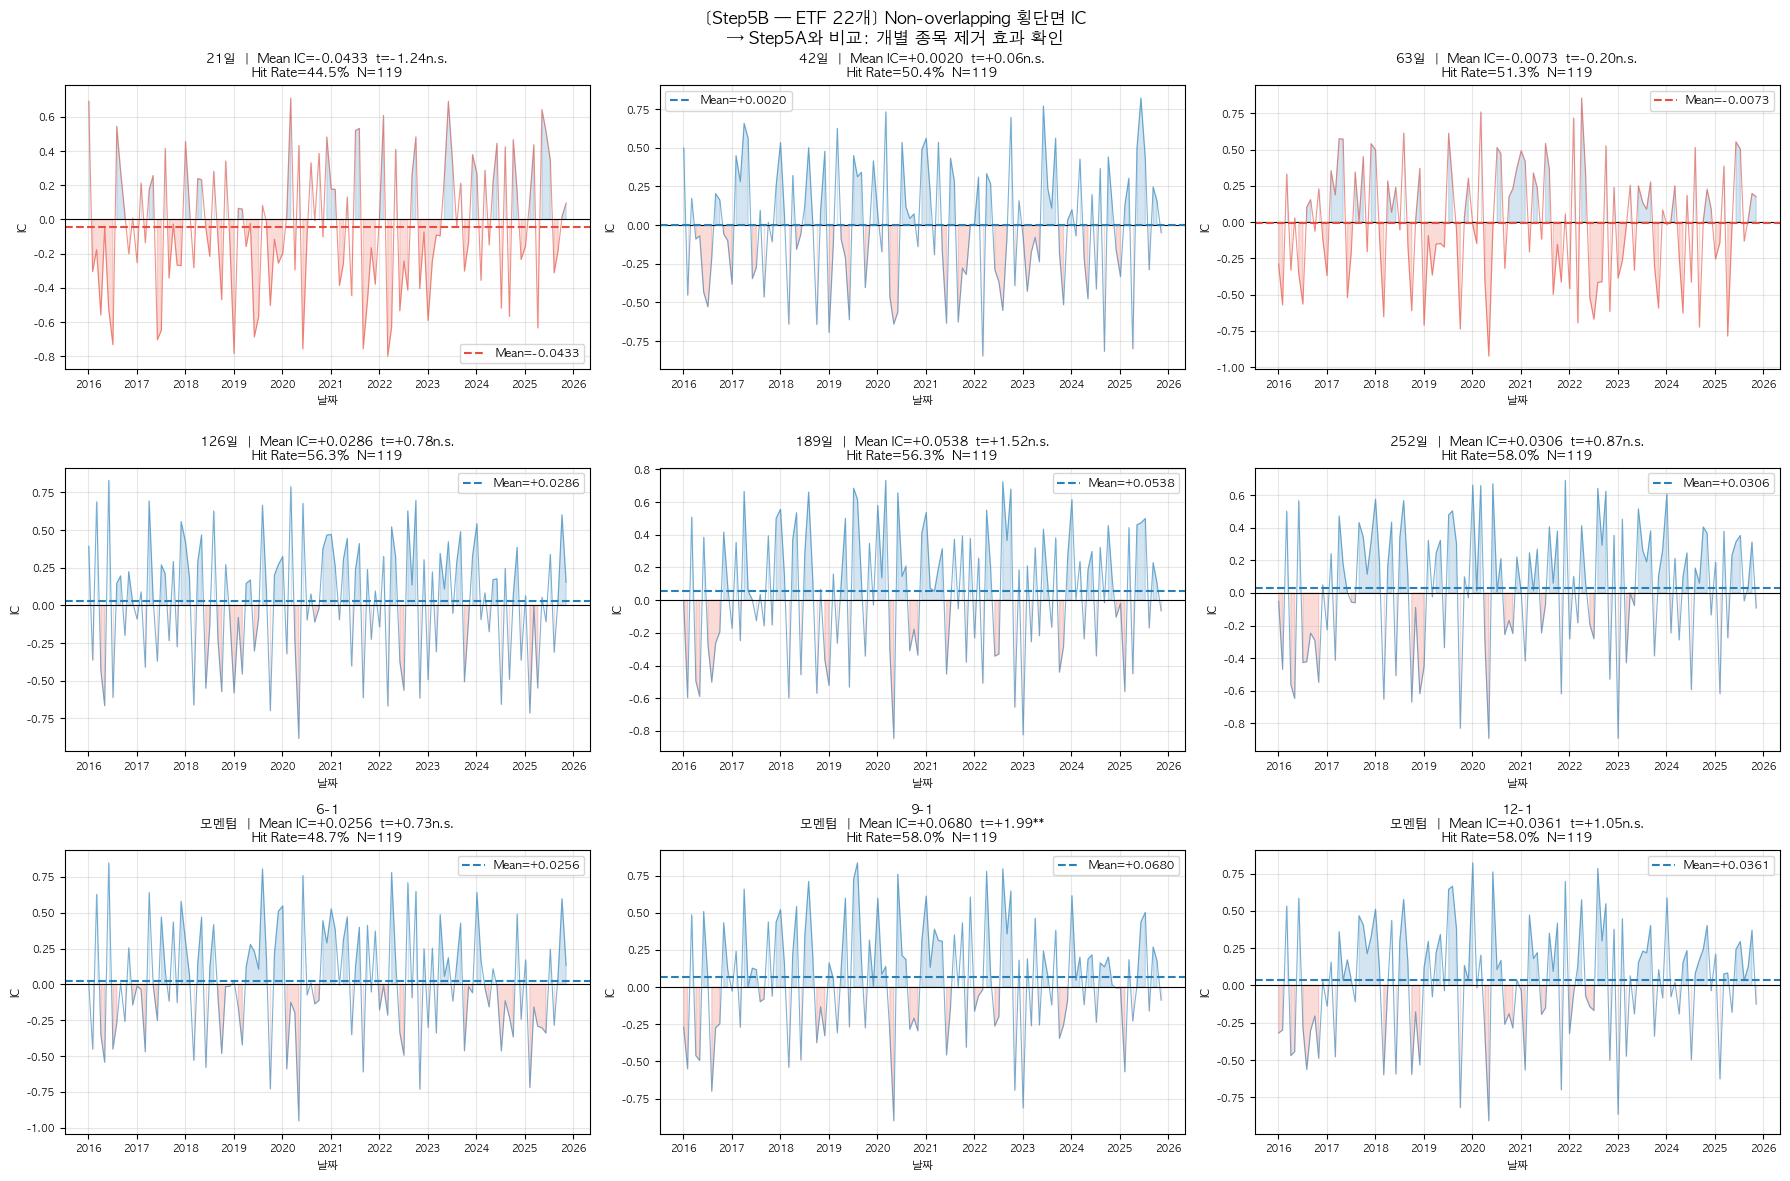

저장: images/step5b_eda_nonoverlap_ic.png


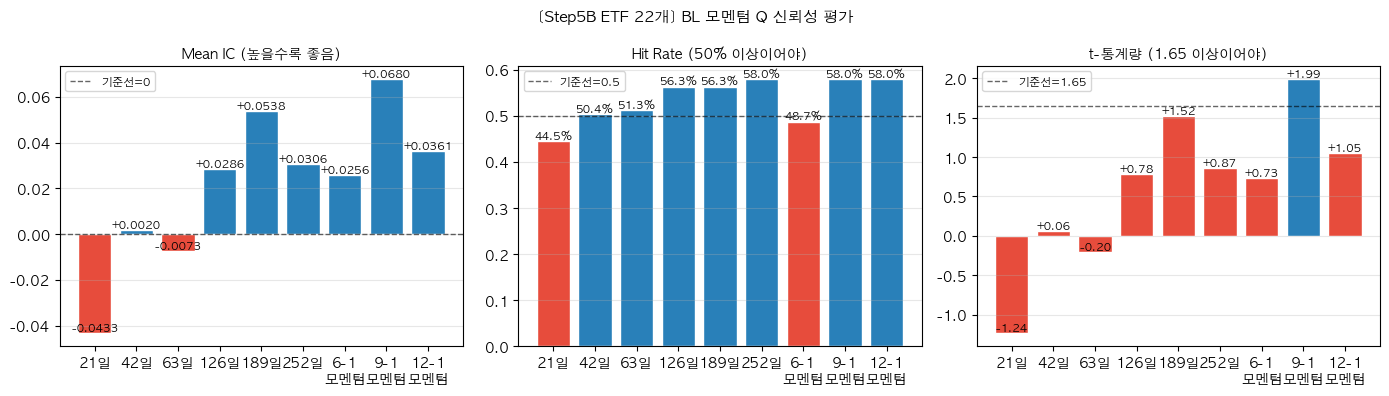

저장: images/step5b_eda_ic_summary.png


In [7]:
from scipy.stats import spearmanr, ttest_1samp
import warnings
warnings.filterwarnings('ignore')

WINDOWS_EDA  = [21, 42, 63, 126, 189, 252, '6-1', '9-1', '12-1']
SKIP_WIN_MAP = {'6-1': (21,105), '9-1': (21,168), '12-1': (21,231)}
FORWARD_DAYS = 21

def compute_nonoverlap_cs_ic(prices_df, window, forward_days=FORWARD_DAYS,
                              start=ANALYSIS_START, step=None):
    """Non-overlapping 횡단면 IC (Step5A와 동일)"""
    step = step or forward_days
    dates_full = prices_df.loc[start:].index
    if window in SKIP_WIN_MAP:
        skip, lookback = SKIP_WIN_MAP[window]
        momentum = prices_df.shift(skip).pct_change(lookback)
    else:
        momentum = prices_df.pct_change(window)
    future_r = prices_df.pct_change(forward_days).shift(-forward_days)
    ic_list = []
    for i in range(0, len(dates_full) - forward_days, step):
        t = dates_full[i]
        mom_row = momentum.loc[t].dropna()
        fut_row = future_r.loc[t].reindex(mom_row.index).dropna()
        common  = mom_row.index.intersection(fut_row.index)
        if len(common) < 5:
            continue
        ic, _ = spearmanr(mom_row[common], fut_row[common])
        ic_list.append({'date': t, 'ic': ic})
    return pd.DataFrame(ic_list).set_index('date') if ic_list else pd.DataFrame()


print("ETF 22개 Non-overlapping 횡단면 IC 계산 중 (21일 간격)...")
print(f"{'윈도우':>6s} | {'관측수':>5s} | {'Mean IC':>9s} | {'Std IC':>8s} | {'t-stat':>7s} | {'p-val':>7s} | {'Hit Rate':>9s} | 유의성")
print("-" * 80)

ic_nonoverlap = {}
for w in WINDOWS_EDA:
    df = compute_nonoverlap_cs_ic(etf_prices[ETF_UNIVERSE], w)
    if df.empty:
        continue
    ic_nonoverlap[w] = df
    series = df['ic'].dropna()
    n       = len(series)
    mean_ic = series.mean()
    std_ic  = series.std()
    t_stat  = mean_ic / (std_ic / np.sqrt(n)) if std_ic > 0 else 0
    from scipy.stats import t as t_dist
    p_val   = t_dist.sf(t_stat, df=n-1)
    hit_rate = (series > 0).mean()
    sig = '***' if p_val < 0.01 else ('**' if p_val < 0.05 else ('*' if p_val < 0.10 else ''))
    w_label = w if isinstance(w, str) else f"{w}일"
    print(f"{w_label:>8s} | {n:>5d} | {mean_ic:>+9.4f} | {std_ic:>8.4f} | {t_stat:>+7.2f} | {p_val:>7.4f} | {hit_rate:>9.1%} | {sig}")

# 시각화
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for ax, w in zip(axes, WINDOWS_EDA):
    if w not in ic_nonoverlap:
        ax.set_visible(False); continue
    df = ic_nonoverlap[w]
    series = df['ic'].dropna()
    mean_ic = series.mean()
    t_stat  = mean_ic / (series.std() / np.sqrt(len(series)))
    hit     = (series > 0).mean()
    color = '#2980b9' if mean_ic >= 0 else '#e74c3c'
    ax.plot(df.index, df['ic'], color=color, alpha=0.6, linewidth=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axhline(mean_ic, color=color, linewidth=1.5, linestyle='--', label=f'Mean={mean_ic:+.4f}')
    ax.fill_between(df.index, df['ic'], 0, where=df['ic'] > 0, alpha=0.2, color='#2980b9')
    ax.fill_between(df.index, df['ic'], 0, where=df['ic'] < 0, alpha=0.2, color='#e74c3c')
    sig_str = '***' if abs(t_stat) > 2.58 else ('**' if abs(t_stat) > 1.96 else ('*' if abs(t_stat) > 1.65 else 'n.s.'))
    win_label = f'{w}\n모멘텀' if isinstance(w, str) else f'{w}일'
    ax.set_title(f'{win_label}  |  Mean IC={mean_ic:+.4f}  t={t_stat:+.2f}{sig_str}\nHit Rate={hit:.1%}  N={len(series)}', fontsize=9)
    ax.set_xlabel('날짜', fontsize=8); ax.set_ylabel('IC', fontsize=8)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.tick_params(labelsize=7)

plt.suptitle('[Step5B — ETF 22개] Non-overlapping 횡단면 IC\n→ Step5A와 비교: 개별 종목 제거 효과 확인', fontsize=12)
plt.tight_layout()
plt.savefig(IMAGES / 'step5b_eda_nonoverlap_ic.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: images/step5b_eda_nonoverlap_ic.png")

# 요약 막대 차트
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))
windows_sorted = sorted(ic_nonoverlap.keys(), key=lambda w: (1, int(w.split('-')[0])) if isinstance(w, str) else (0, w))
mean_ics   = [ic_nonoverlap[w]['ic'].mean() for w in windows_sorted]
hit_rates  = [(ic_nonoverlap[w]['ic'] > 0).mean() for w in windows_sorted]
t_stats    = [ic_nonoverlap[w]['ic'].mean() / (ic_nonoverlap[w]['ic'].std() / np.sqrt(len(ic_nonoverlap[w]))) for w in windows_sorted]
xlabels = [f'{w}\n모멘텀' if isinstance(w, str) else f'{w}일' for w in windows_sorted]
for ax2, vals, title, fmt, thresh in zip(
    axes2, [mean_ics, hit_rates, t_stats],
    ['Mean IC (높을수록 좋음)', 'Hit Rate (50% 이상이어야)', 't-통계량 (1.65 이상이어야)'],
    ['ic', 'pct', 'float'], [0, 0.5, 1.65]
):
    colors = ['#2980b9' if v >= thresh else '#e74c3c' for v in vals]
    bars = ax2.bar(xlabels, vals, color=colors, edgecolor='white')
    ax2.axhline(thresh, color='black', linewidth=1, linestyle='--', alpha=0.6, label=f'기준선={thresh}')
    ax2.set_title(title, fontsize=10); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        label = f'{v:+.4f}' if fmt == 'ic' else (f'{v:.1%}' if fmt == 'pct' else f'{v:+.2f}')
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), label, ha='center', va='bottom', fontsize=8)
plt.suptitle('[Step5B ETF 22개] BL 모멘텀 Q 신뢰성 평가', fontsize=11)
plt.tight_layout()
plt.savefig(IMAGES / 'step5b_eda_ic_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: images/step5b_eda_ic_summary.png")

## 셀 8: ETF별 IC 분석

ETF별 Non-overlapping IC 계산 중...
완료: 22개 ETF
양수 IC 보유 ETF: 16개 / 전체 22개


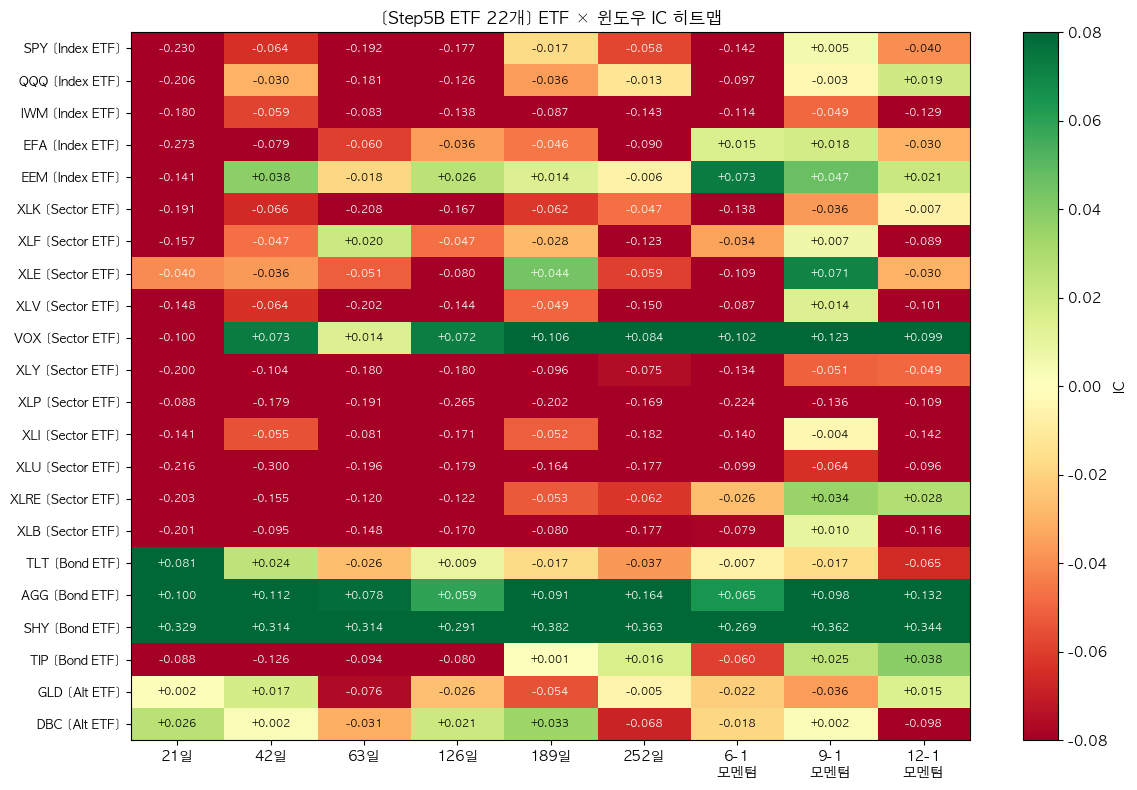

저장: images/step5b_etf_ic_heatmap.png


In [8]:
def compute_asset_nonoverlap_ic(price_series, window, forward_days=FORWARD_DAYS,
                                 start=ANALYSIS_START, step=None):
    step = step or forward_days
    dates_full = price_series.loc[start:].index
    if window in SKIP_WIN_MAP:
        skip, lookback = SKIP_WIN_MAP[window]
        momentum = price_series.shift(skip).pct_change(lookback)
    else:
        momentum = price_series.pct_change(window)
    future_r = price_series.pct_change(forward_days).shift(-forward_days)
    mom_vals, fut_vals = [], []
    for i in range(0, len(dates_full) - forward_days, step):
        t = dates_full[i]
        m = momentum.get(t, np.nan)
        f = future_r.get(t, np.nan)
        if pd.notna(m) and pd.notna(f):
            mom_vals.append(m); fut_vals.append(f)
    if len(mom_vals) < 10:
        return np.nan
    ic, _ = spearmanr(mom_vals, fut_vals)
    return ic


print('ETF별 Non-overlapping IC 계산 중...')
asset_ic_table = {}
for ticker in ETF_UNIVERSE:
    if ticker not in etf_prices.columns:
        continue
    p_series = etf_prices[ticker].dropna()
    ic_per_w = {}
    for w in WINDOWS_EDA:
        ic_val = compute_asset_nonoverlap_ic(p_series, w)
        if pd.notna(ic_val):
            ic_per_w[w] = ic_val
    if ic_per_w:
        asset_ic_table[ticker] = ic_per_w

print(f'완료: {len(asset_ic_table)}개 ETF')

# ETF별 최적 윈도우
asset_best = {}
for ticker, ic_dict in asset_ic_table.items():
    pos = {w: v for w, v in ic_dict.items() if v > 0}
    asset_best[ticker] = max(pos, key=lambda w: pos[w]) if pos else max(ic_dict, key=lambda w: ic_dict[w])

pos_count = sum(1 for t, w in asset_best.items() if asset_ic_table[t][w] > 0)
print(f'양수 IC 보유 ETF: {pos_count}개 / 전체 {len(asset_best)}개')

# 히트맵
ic_df = pd.DataFrame(asset_ic_table).T.reindex(columns=WINDOWS_EDA).fillna(0)
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(ic_df.values, aspect='auto', cmap='RdYlGn', vmin=-0.08, vmax=0.08)
ax.set_xticks(range(len(WINDOWS_EDA)))
ax.set_xticklabels([f'{w}\n모멘텀' if isinstance(w, str) else f'{w}일' for w in WINDOWS_EDA])
ax.set_yticks(range(len(ic_df)))
ax.set_yticklabels([f'{t} [{ETF_TYPE.get(t,"")}]' for t in ic_df.index], fontsize=9)
for row_i in range(len(ic_df)):
    for col_j in range(len(WINDOWS_EDA)):
        val = ic_df.iloc[row_i, col_j]
        txt_color = 'white' if abs(val) > 0.04 else 'black'
        ax.text(col_j, row_i, f'{val:+.3f}', ha='center', va='center', fontsize=7.5, color=txt_color)
plt.colorbar(im, ax=ax, label='IC')
ax.set_title('[Step5B ETF 22개] ETF × 윈도우 IC 히트맵', fontsize=12)
plt.tight_layout()
plt.savefig(IMAGES / 'step5b_etf_ic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: images/step5b_etf_ic_heatmap.png')

## 셀 9: Walk-Forward 백테스트 (고정 ETF 유니버스)

- 유니버스 고정: 22개 ETF (동적 갱신 없음)
- 21거래일마다 BL 리밸런싱
- 절대 모멘텀 필터: 12-1 > T-bill → active

In [9]:
analysis_days = etf_prices.loc[ANALYSIS_START:].index
n_days = len(analysis_days)
n_all  = len(ETF_UNIVERSE)

current_weights = {p: pd.Series(1.0 / n_all, index=ETF_UNIVERSE) for p in PROFILES}
current_weights['EqualWeight'] = pd.Series(1.0 / n_all, index=ETF_UNIVERSE)

port_values      = {p: [1.0] for p in list(PROFILES.keys()) + ['EqualWeight']}
rebalance_log    = []
exclusion_rate   = []
active_count_log = []
omega_logs       = []

print(f'분석 기간: {analysis_days[0].date()} ~ {analysis_days[-1].date()} ({n_days}거래일)')
print(f'고정 ETF 유니버스: {n_all}개')
print(f'Step5B: 듀얼 모멘텀 필터 + 모멘텀 Q | Prior: Risk Parity | Omega: Idzorek\n')

for i, date in enumerate(analysis_days[1:], 1):
    prev_date = analysis_days[i - 1]

    ret = {}
    for t in ETF_UNIVERSE:
        if t in etf_prices.columns:
            p0 = etf_prices.at[prev_date, t] if prev_date in etf_prices.index else np.nan
            p1 = etf_prices.at[date, t]      if date      in etf_prices.index else np.nan
            ret[t] = (p1 / p0 - 1) if (pd.notna(p0) and pd.notna(p1) and p0 > 0) else 0.0
        else:
            ret[t] = 0.0

    for p in list(PROFILES.keys()) + ['EqualWeight']:
        w = current_weights[p]
        port_ret = sum(w.get(t, 0.0) * ret.get(t, 0.0) for t in ETF_UNIVERSE)
        port_values[p].append(port_values[p][-1] * (1 + port_ret))

    if i % REBALANCE_FREQ == 0:
        prices_win = etf_prices.loc[:date, ETF_UNIVERSE]
        if len(prices_win) < COV_WIN + 253:
            continue

        active_tickers, excluded_tickers = apply_absolute_momentum_filter(
            ETF_UNIVERSE, prices_win, date, CACHE
        )
        n_active   = len(active_tickers)
        n_excluded = len(excluded_tickers)
        exclusion_rate.append(n_excluded / max(n_active + n_excluded, 1))
        active_count_log.append({'date': date, 'active': n_active, 'excluded': n_excluded})

        if n_active < 2:
            continue

        active_win = prices_win[active_tickers]
        recent = active_win.iloc[-COV_WIN:]
        log_r  = np.log(recent / recent.shift(1)).dropna()
        if log_r.shape[0] < 60:
            continue

        lw = LedoitWolf()
        lw.fit(log_r)
        cov = lw.covariance_ * 252

        pi_raw = compute_prior_risk_parity(cov, LAM)
        pi = pd.Series(pi_raw.values, index=active_tickers)

        active_eq   = [t for t in EQUITY_TICKERS if t in active_tickers]
        active_bond = [t for t in BOND_TICKERS   if t in active_tickers]

        Q = compute_momentum_Q_typed(
            active_win, active_eq, active_bond
        ).reindex(active_tickers).fillna(0)
        omega, confidence = compute_omega_idzorek(Q, cov, TAU)
        mu_bl, sigma_bl = black_litterman(pi, cov, Q, omega, TAU)

        diag_omega = np.diag(omega)
        diag_prior = np.diag(TAU * cov)
        omega_logs.append({
            'date': date,
            'mean_confidence':      np.mean(confidence),
            'mean_rel_uncertainty': np.mean(diag_omega / (diag_prior + 1e-9)),
        })

        for p, prof in PROFILES.items():
            if not active_eq and not active_bond:
                current_weights[p] = pd.Series(0.0, index=ETF_UNIVERSE)
                continue
            w_active = mvo_optimize_etf(
                mu_bl, sigma_bl, prof['gamma'],
                equity_tickers  = active_eq,
                bond_tickers    = active_bond,
                max_equity_weight = prof['max_equity_weight'],
                max_bond_total    = prof['max_bond_total'],
                max_single_bond   = prof['max_single_bond'],
            )
            w_full = pd.Series(0.0, index=ETF_UNIVERSE)
            for t in active_tickers:
                if t in w_active.index:
                    w_full[t] = w_active[t]
            if w_full.sum() > 0:
                w_full /= w_full.sum()
            current_weights[p] = w_full

        n_ew = max(n_active, 1)
        current_weights['EqualWeight'] = pd.Series(
            {t: (1.0/n_ew if t in active_tickers else 0.0) for t in ETF_UNIVERSE}
        )
        rebalance_log.append({'date': date, 'n_active': n_active})

print(f'\n백테스트 완료! 총 리밸런싱: {len(rebalance_log)}회')

if omega_logs:
    om_df = pd.DataFrame(omega_logs)
    print()
    print('=' * 52)
    print('   [Black-Litterman Omega & Confidence 요약]')
    print('=' * 52)
    print(f'평균 신뢰도 (c):              {om_df["mean_confidence"].mean():.4f}')
    print(f'평균 상대적 불확실성 (Ω/τΣ): {om_df["mean_rel_uncertainty"].mean():.2f}배')
    print('─' * 52)
    print('※ 신뢰도(c)가 c_max(0.9)에 가까울수록 Q가 μ_BL에 강하게 반영됨')
    print('※ Ω/τΣ >> 1 이면 Prior(Risk Parity) 중심, ≈1 이면 Q와 균형')
    print('=' * 52)

if active_count_log:
    cnt_df = pd.DataFrame(active_count_log)
    avg_ex = np.mean(exclusion_rate) * 100
    print()
    print('=' * 52)
    print('   [듀얼 모멘텀 필터 — Active ETF 수]')
    print('=' * 52)
    print(f'전체 유니버스: {n_all}개 | 평균 active: {cnt_df["active"].mean():.1f}개 | 평균 편출: {avg_ex:.1f}%')
    print(f'최소 active: {cnt_df["active"].min()}개  |  최대 active: {cnt_df["active"].max()}개')
    print('=' * 52)

분석 기간: 2016-01-04 ~ 2025-12-30 (2513거래일)
고정 ETF 유니버스: 22개
Step5B: 듀얼 모멘텀 필터 + 모멘텀 Q | Prior: Risk Parity | Omega: Idzorek


백테스트 완료! 총 리밸런싱: 119회

   [Black-Litterman Omega & Confidence 요약]
평균 신뢰도 (c):              0.3922
평균 상대적 불확실성 (Ω/τΣ): 2.30배
────────────────────────────────────────────────────
※ 신뢰도(c)가 c_max(0.9)에 가까울수록 Q가 μ_BL에 강하게 반영됨
※ Ω/τΣ >> 1 이면 Prior(Risk Parity) 중심, ≈1 이면 Q와 균형

   [듀얼 모멘텀 필터 — Active ETF 수]
전체 유니버스: 22개 | 평균 active: 14.0개 | 평균 편출: 36.4%
최소 active: 2개  |  최대 active: 20개


In [10]:
def compute_metrics(values, dates_list):
    vals = np.array(values)
    rets = np.diff(vals) / vals[:-1]
    n_years = (pd.Timestamp(dates_list[-1]) - pd.Timestamp(dates_list[0])).days / 365.25
    total_ret = vals[-1] / vals[0] - 1
    ann_ret = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else 0
    ann_vol = rets.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    running_max = np.maximum.accumulate(vals)
    mdd = ((vals - running_max) / running_max).min()
    down = rets[rets < 0]
    sortino = ann_ret / (down.std() * np.sqrt(252)) if len(down) > 0 else 0
    calmar = ann_ret / abs(mdd) if mdd != 0 else 0
    return {'ann_return': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe,
            'mdd': mdd, 'sortino': sortino, 'calmar': calmar, 'total_return': total_ret}


dates = list(analysis_days)
metrics = {}
for p in list(PROFILES.keys()) + ['EqualWeight']:
    metrics[p] = compute_metrics(port_values[p], dates)

spy_cache = CACHE / 'spy_prices.pkl'
if spy_cache.exists():
    with open(spy_cache, 'rb') as f:
        spy_raw = pickle.load(f)
else:
    spy_raw = yf.download('SPY', start=ANALYSIS_START, end=PRICE_END, auto_adjust=True)['Close'].squeeze()
    with open(spy_cache, 'wb') as f:
        pickle.dump(spy_raw, f)

spy_aligned = spy_raw.loc[ANALYSIS_START:]
spy_norm = (spy_aligned / spy_aligned.iloc[0]).values
metrics['SPY_BnH'] = compute_metrics(spy_norm, list(spy_aligned.index))

print('=== [Step5B ETF 22개] 성능 요약 ===')
header = f'{"전략":18s} {"연수익률":>10s} {"변동성":>10s} {"Sharpe":>8s} {"MDD":>10s} {"Sortino":>10s} {"Calmar":>8s}'
print(header)
print('-' * 80)
for name, m in metrics.items():
    print(f'{name:18s} {m["ann_return"]:>10.2%} {m["ann_vol"]:>10.2%} '
          f'{m["sharpe"]:>8.3f} {m["mdd"]:>10.2%} {m["sortino"]:>10.3f} {m["calmar"]:>8.3f}')

metrics_df = pd.DataFrame(metrics).T
metrics_df.to_csv(DATA / 'step5b_metrics.csv')
print('\n성능 지표 저장: data/step5b_metrics.csv')

=== [Step5B ETF 22개] 성능 요약 ===
전략                       연수익률        변동성   Sharpe        MDD    Sortino   Calmar
--------------------------------------------------------------------------------
Aggressive              9.08%     16.25%    0.559    -31.25%      0.706    0.290
Neutral                 9.61%     14.13%    0.680    -26.18%      0.853    0.367
Conservative            9.97%     12.55%    0.794    -22.47%      0.989    0.444
EqualWeight            10.27%     13.88%    0.740    -27.15%      0.887    0.378
SPY_BnH                14.98%     18.01%    0.832    -33.72%      0.999    0.444

성능 지표 저장: data/step5b_metrics.csv


## 셀 10: 시각화

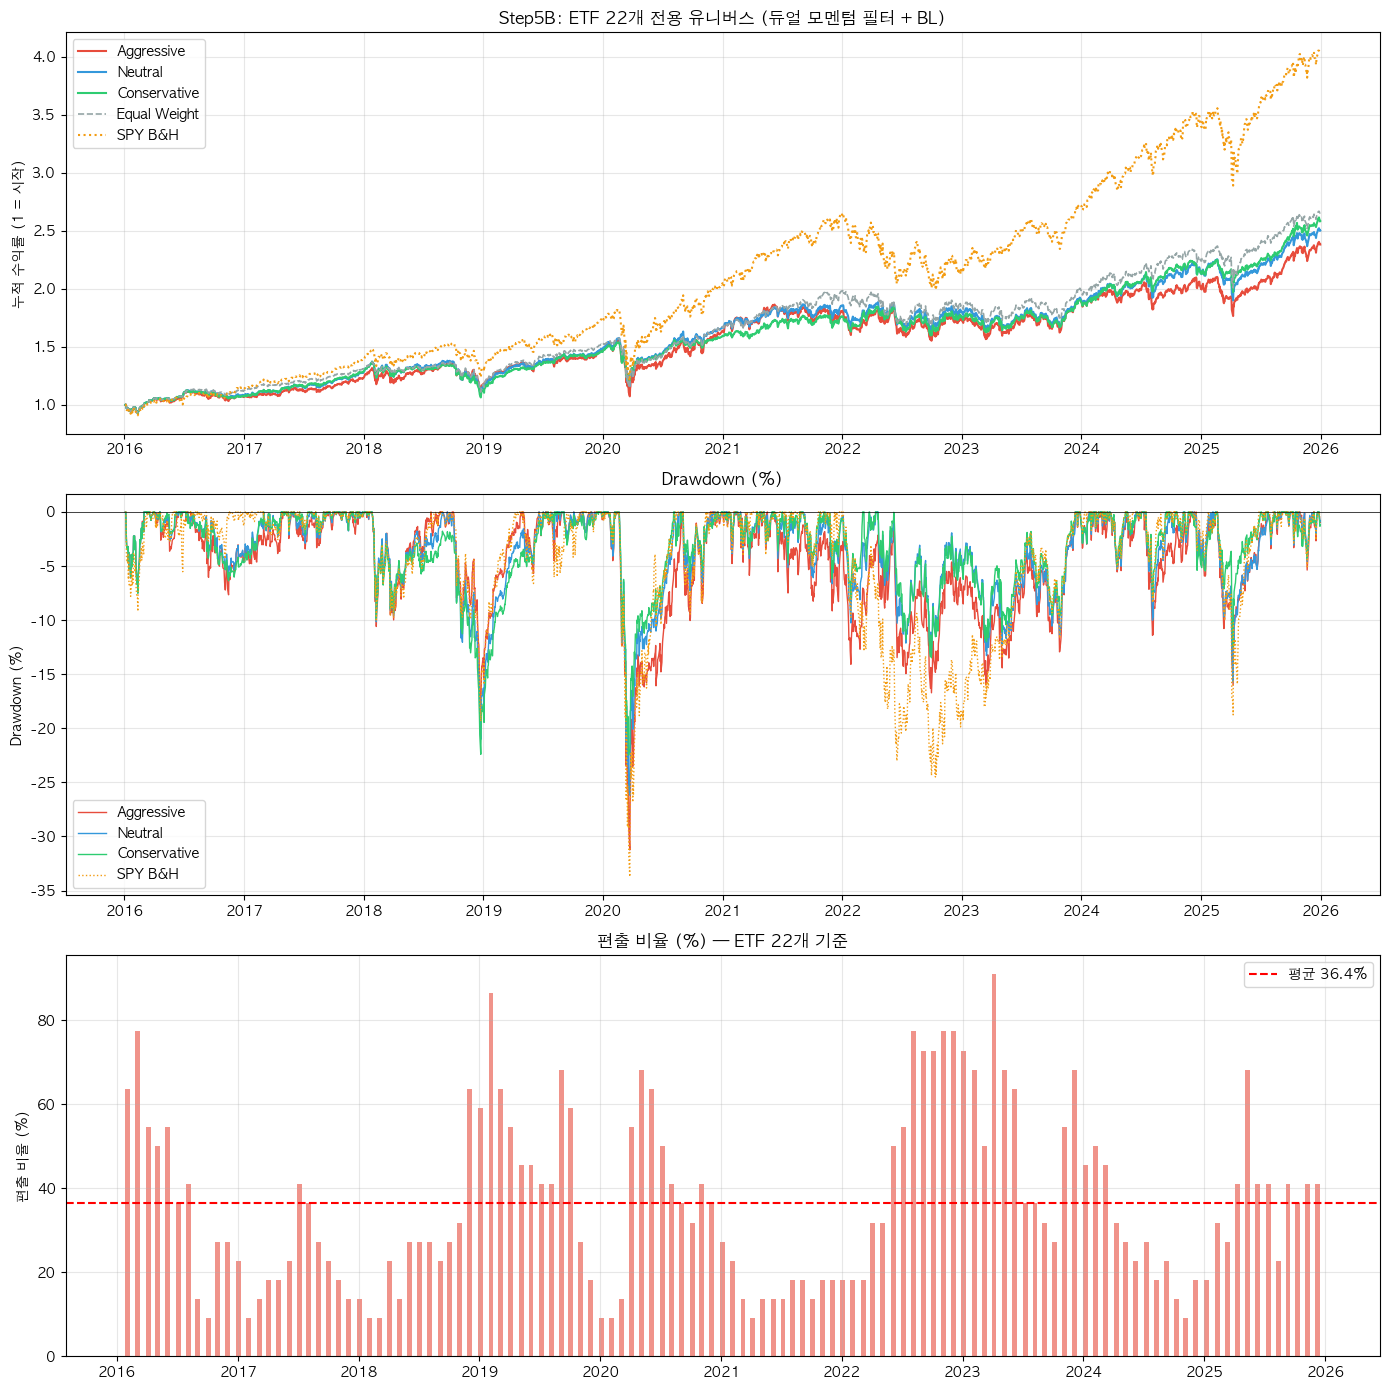

저장: images/step5b_01_cumulative.png


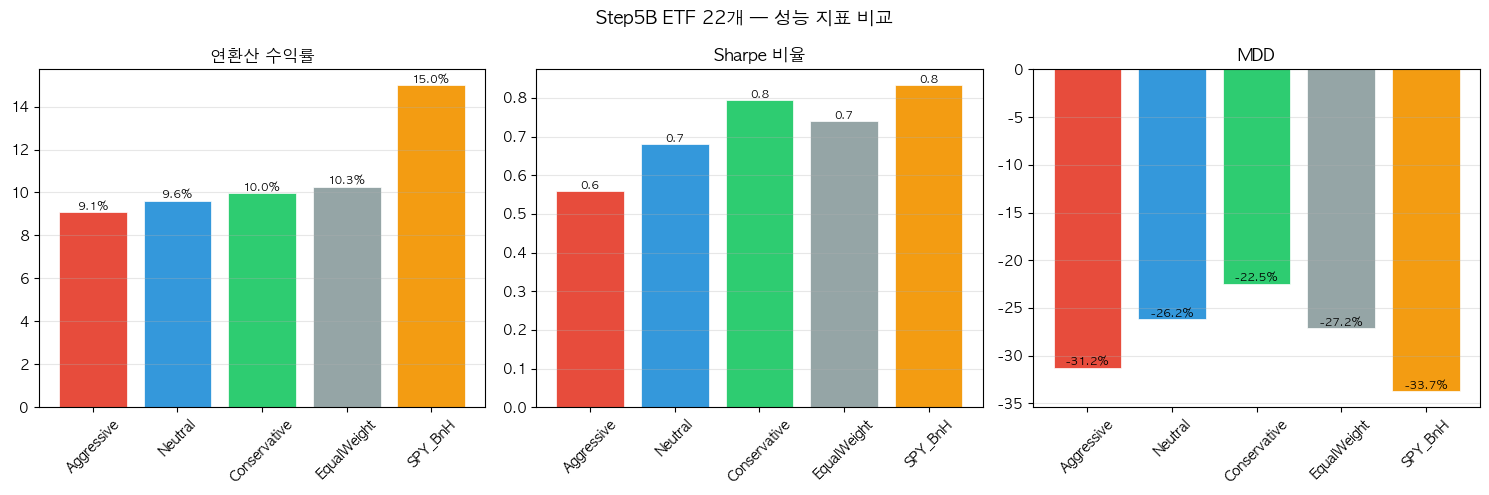

저장: images/step5b_02_metrics.png


In [11]:
COLORS = {
    'Aggressive': '#e74c3c', 'Neutral': '#3498db', 'Conservative': '#2ecc71',
    'EqualWeight': '#95a5a6', 'SPY_BnH': '#f39c12'
}

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

ax = axes[0]
for p in PROFILES:
    ax.plot(dates, port_values[p], label=p, color=COLORS[p], linewidth=1.5)
ax.plot(dates, port_values['EqualWeight'], label='Equal Weight', color=COLORS['EqualWeight'],
        linewidth=1.2, linestyle='--')
spy_dates = list(spy_aligned.index)
ax.plot(spy_dates, spy_norm, label='SPY B&H', color=COLORS['SPY_BnH'], linewidth=1.5, linestyle=':')
ax.set_title('Step5B: ETF 22개 전용 유니버스 (듀얼 모멘텀 필터 + BL)', fontsize=12)
ax.set_ylabel('누적 수익률 (1 = 시작)'); ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
for p in PROFILES:
    vals = np.array(port_values[p])
    rmax = np.maximum.accumulate(vals)
    dd = (vals - rmax) / rmax * 100
    ax2.plot(dates, dd, label=p, color=COLORS[p], linewidth=1)
spy_rmax = np.maximum.accumulate(spy_norm)
spy_dd = (spy_norm - spy_rmax) / spy_rmax * 100
ax2.plot(spy_dates, spy_dd, label='SPY B&H', color=COLORS['SPY_BnH'], linestyle=':', linewidth=1)
ax2.set_title('Drawdown (%)'); ax2.set_ylabel('Drawdown (%)'); ax2.axhline(0, color='black', linewidth=0.5)
ax2.legend(); ax2.grid(True, alpha=0.3)

if active_count_log:
    ax3 = axes[2]
    cnt_df2 = pd.DataFrame(active_count_log)
    ax3.bar(cnt_df2['date'], (cnt_df2['excluded'] / n_all * 100),
            color='#e74c3c', alpha=0.6, width=15)
    ax3.axhline(np.mean(exclusion_rate)*100, color='red', linestyle='--',
                label=f'평균 {np.mean(exclusion_rate)*100:.1f}%')
    ax3.set_title(f'편출 비율 (%) — ETF {n_all}개 기준')
    ax3.set_ylabel('편출 비율 (%)'); ax3.legend(); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES / 'step5b_01_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: images/step5b_01_cumulative.png')

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
names = list(metrics.keys())
colors_list = [COLORS.get(n, '#7f8c8d') for n in names]
for ax, metric, title, fmt in zip(
    axes2, ['ann_return', 'sharpe', 'mdd'],
    ['연환산 수익률', 'Sharpe 비율', 'MDD'], ['percent', 'float', 'percent']
):
    vals_plot = [metrics[n][metric] * (100 if fmt == 'percent' else 1) for n in names]
    bars = ax.bar(names, vals_plot, color=colors_list, edgecolor='white', linewidth=0.5)
    ax.set_title(title); ax.tick_params(axis='x', rotation=45)
    unit = '%' if fmt == 'percent' else ''
    for bar, v in zip(bars, vals_plot):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.1f}{unit}', ha='center', va='bottom', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
plt.suptitle('Step5B ETF 22개 — 성능 지표 비교', fontsize=13)
plt.tight_layout()
plt.savefig(IMAGES / 'step5b_02_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: images/step5b_02_metrics.png')